# Notebook 06: Real Population Analysis

This notebook runs the full crossing, equilibrium, and optimization pipeline on the **real SRK genotype data** from *Lepidium papilliferum* (124 ingroup individuals across 24 populations).

**Prerequisites**: Run `00_load_data.ipynb` first to generate `data/population.pkl`.

## Analysis Structure

1. **Within-population analysis** — For each major population (>= 5 individuals), optimize crossing strategy independently
2. **Cross-population analysis** — Treat all 124 individuals as a single population to identify the best crosses species-wide

For both analyses, we simulate **1, 2, and 5 years** (= generations) and compare four strategies:
- **Random mating** — baseline (no selection pressure)
- **Optimized crossing (no preservation)** — gradient descent minimizing variance, but can lose rare alleles
- **Optimized + preservation** — adds elitism, mandatory rare-allele crosses, and optimizer penalty
- **Optimized + preservation + demography** — adds logistic population growth with demographic stochasticity and tracks effective population size (Ne)

The demographic strategy models realistic population dynamics: populations grow toward a carrying capacity K with Poisson-distributed noise, and Ne is computed from SI compatibility structure.

## Key Changes

- Genotypes are **directly assigned** from zygosity data (no imputation)
- Individuals are grouped by **Pop** (biological population), not Library
- **Demographic dynamics** added: logistic growth, stochastic population size, Ne tracking

In [1]:
import os
import sys
import pickle
import itertools
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

# Import all shared utilities
sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, form_gametes, is_compatible,
    cross, crossing_compatibility, sample_offspring, simulate_generation,
    distance_from_equilibrium, enumerate_compatible_crosses,
    compute_greedy_weights, compute_optimal_weights,
    identify_rare_alleles, get_mandatory_rare_crosses, select_elites,
    logistic_n_offspring, effective_population_size, ne_harmonic_mean,
)

print("All utilities loaded from polyploid_utils (with allele preservation & demography).")

All utilities loaded from polyploid_utils (with allele preservation & demography).


## 1. Load Population Data

In [2]:
DATA_DIR = os.path.join("..", "data")
pkl_path = os.path.join(DATA_DIR, "population.pkl")

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

population = data["population"]
individual_names = data["individual_names"]
allele_pool_full = data["allele_pool"]
name_to_id = data["name_to_id"]
id_to_name = data["id_to_name"]
pop_map = data["pop_map"]
pop_populations = data["pop_populations"]
pop_individuals = data["pop_individuals"]
core_allele_ids = data["core_allele_ids"]

print(f"Population: {len(population)} individuals")
print(f"Full allele pool: {len(allele_pool_full)} alleles")
print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Unique genotypes: {len(set(population))}")
print(f"Populations: {len(pop_populations)}")

Population: 124 individuals
Full allele pool: 94 alleles
Core alleles (in 2+ individuals): 53
Unique genotypes: 102
Populations: 24


## 2. Population Overview

Individuals are grouped by the **Pop** field (biological populations). Major populations (>= 5 individuals) are analyzed independently for within-population crossing. All individuals are also analyzed together for cross-population strategy.

In [3]:
# Identify major vs minor populations
MAJOR_POP_THRESHOLD = 5
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= MAJOR_POP_THRESHOLD])
minor_pops = sorted([p for p, inds in pop_populations.items() if len(inds) < MAJOR_POP_THRESHOLD])

pop_colors = {
    "25": "#1f77b4",
    "76": "#ff7f0e",
    "67": "#2ca02c",
    "27": "#d62728",
}

print("=== Major Populations (within-population analysis) ===")
print(f"{'Pop':<8} {'N':>5} {'Alleles':>8} {'Unique geno':>12} {'Chi-sq':>10} {'Variance':>10}")
print("-" * 56)
for pop in major_pops:
    genotypes = pop_populations[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    d = distance_from_equilibrium(genotypes, alleles)
    print(f"{pop:<8} {len(genotypes):>5} {len(alleles):>8} {len(set(genotypes)):>12} "
          f"{d['chi_squared']:>10.4f} {d['variance']:>10.6f}")

print(f"\n=== Minor Populations ({len(minor_pops)} pops, <{MAJOR_POP_THRESHOLD} individuals each) ===")
minor_total = sum(len(pop_populations[p]) for p in minor_pops)
print(f"Total individuals in minor pops: {minor_total}")
print(f"Populations: {', '.join(f'{p}(n={len(pop_populations[p])})' for p in minor_pops)}")

# Overall stats
all_alleles = sorted(set(a for g in population for a in g))
d_all = distance_from_equilibrium(population, all_alleles)
print(f"\n=== All Individuals Combined ===")
print(f"Total: {len(population)} individuals, {len(all_alleles)} alleles, "
      f"{len(set(population))} unique genotypes")
print(f"Chi-squared: {d_all['chi_squared']:.4f}, Variance: {d_all['variance']:.6f}")

=== Major Populations (within-population analysis) ===
Pop          N  Alleles  Unique geno     Chi-sq   Variance
--------------------------------------------------------
25          31       26           21     1.1813   0.001748
27          15       17           14     0.1333   0.000461
67          22       20           21     0.2707   0.000677
76          27       23           26     0.4119   0.000779

=== Minor Populations (20 pops, <5 individuals each) ===
Total individuals in minor pops: 29
Populations: 118(n=3), 18(n=3), 24(n=1), 24-14(n=1), 26-3(n=1), 29(n=1), 38(n=1), 405(n=1), 48(n=1), 52(n=1), 61(n=1), 68(n=3), 70(n=2), 702-24(n=1), 702-3(n=1), 709(n=1), 712-5(n=1), 715-1(n=1), 8(n=3), 96-16(n=1)

=== All Individuals Combined ===
Total: 124 individuals, 92 alleles, 102 unique genotypes
Chi-squared: 0.7322, Variance: 0.000087


---

# Part A: Within-Population Analysis

For each major population, we:
1. Enumerate SI-compatible crosses
2. Optimize crossing weights using gradient descent (with and without allele preservation)
3. Simulate 5 generations comparing: random mating, **optimized with preservation** (recommended), and original optimization (no preservation)
4. Show allele frequency distributions at Year 0 (baseline), 1, 2, and 5

In [4]:
%%time

# Build per-population data structures
group_data = {}

for pop in major_pops:
    genotypes = pop_populations[pop]
    names = pop_individuals[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    target = 1.0 / len(alleles)

    cc, aem = enumerate_compatible_crosses(genotypes, alleles)
    n_total = len(genotypes) * (len(genotypes) - 1)

    group_data[pop] = {
        "pop": genotypes,
        "individuals": names,
        "allele_pool": alleles,
        "target_freq": target,
        "compatible_crosses": cc,
        "allele_effect_matrix": aem,
    }

    print(f"Pop {pop}: {len(genotypes)} ind, {len(alleles)} alleles, "
          f"{len(cc)}/{n_total} compatible crosses ({100*len(cc)/n_total:.1f}%)")

Pop 25: 31 ind, 26 alleles, 871/930 compatible crosses (93.7%)
Pop 27: 15 ind, 17 alleles, 206/210 compatible crosses (98.1%)
Pop 67: 22 ind, 20 alleles, 448/462 compatible crosses (97.0%)
Pop 76: 27 ind, 23 alleles, 669/702 compatible crosses (95.3%)
CPU times: user 48.7 ms, sys: 2.1 ms, total: 50.8 ms
Wall time: 50.7 ms


In [5]:
%%time

for pop in major_pops:
    gd = group_data[pop]
    cc = gd["compatible_crosses"]
    aem = gd["allele_effect_matrix"]
    alleles = gd["allele_pool"]
    n_crosses = len(cc)
    target = gd["target_freq"]

    # Baseline chi-squared
    w0 = np.ones(n_crosses) / n_crosses
    expected = w0 @ aem
    baseline_chi = float(np.sum((expected - target) ** 2 / target))

    optimal_weights, result = compute_optimal_weights(cc, aem, alleles, maxiter=5000)
    gd["optimal_weights"] = optimal_weights
    gd["opt_result"] = result
    gd["baseline_chi"] = baseline_chi

    print(f"Pop {pop}: baseline chi²={baseline_chi:.4f}, "
          f"optimized chi²={result.fun:.6f}, converged={result.success}")

Pop 25: baseline chi²=0.9828, optimized chi²=0.000001, converged=True
Pop 27: baseline chi²=0.1233, optimized chi²=0.000000, converged=True
Pop 67: baseline chi²=0.2410, optimized chi²=0.000000, converged=True
Pop 76: baseline chi²=0.3550, optimized chi²=0.022370, converged=True
CPU times: user 70 ms, sys: 32.4 ms, total: 102 ms
Wall time: 86.5 ms


### Within-Population Simulation (5 Years)

Run adaptive simulations for 5 generations (years). All strategies **recompute** crossing weights each generation based on the current population state. The preservation-aware strategy additionally retains elite rare-allele carriers and performs mandatory rare-allele crosses before filling remaining slots.

In [6]:
N_YEARS = 5
N_TRIALS = 3
SNAPSHOT_YEARS = [0, 1, 2, 5]

def run_adaptive_simulation(pop, allele_pool, n_gen, strategy, n_trials=3,
                            opt_maxiter=200, preserve_rare=False,
                            rare_threshold=0.05, elite_frac=0.1,
                            carrying_capacity=None, growth_rate=0.5,
                            demographic_stochastic=True):
    """Run simulation with optional allele preservation and demographic dynamics.

    Strategies: "random", "optimized"
    When preserve_rare=True, elitism and mandatory rare-allele crosses are applied.
    When carrying_capacity is set, population size varies via logistic growth
    instead of staying fixed.
    """
    all_variances = np.zeros((n_trials, n_gen + 1))
    all_chi_sq = np.zeros((n_trials, n_gen + 1))
    all_extinct = np.zeros((n_trials, n_gen + 1))
    all_endangered = np.zeros((n_trials, n_gen + 1))
    all_pop_sizes = np.zeros((n_trials, n_gen + 1))
    all_ne = np.zeros((n_trials, n_gen + 1))
    snapshots = {}

    for trial in range(n_trials):
        current_pop = list(pop)
        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen] = d["variance"]
            all_chi_sq[trial, gen] = d["chi_squared"]
            all_extinct[trial, gen] = d["extinct_alleles"]
            all_endangered[trial, gen] = d["endangered_alleles"]
            all_pop_sizes[trial, gen] = len(current_pop)

            # Ne computation (skip for very large populations — too slow)
            if len(current_pop) <= 60:
                ne_info = effective_population_size(current_pop, allele_pool)
                all_ne[trial, gen] = ne_info["Ne"]
            else:
                all_ne[trial, gen] = np.nan

            if trial == n_trials - 1:
                snapshots[gen] = list(current_pop)

            if gen < n_gen:
                # Determine offspring count
                if carrying_capacity is not None:
                    n_off = logistic_n_offspring(
                        len(current_pop), carrying_capacity,
                        r=growth_rate, stochastic=demographic_stochastic)
                else:
                    n_off = len(pop)  # fixed at original size

                if strategy == "random":
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)

                    # Identify rare allele indices for optimizer penalty
                    rare_idx = None
                    if preserve_rare:
                        freqs = allele_frequencies(current_pop, allele_pool)
                        sorted_alleles = sorted(allele_pool)
                        rare_idx = [i for i, a in enumerate(sorted_alleles)
                                    if 0 < freqs.get(a, 0) < rare_threshold]

                    weights, _ = compute_optimal_weights(
                        cc, aem, allele_pool, maxiter=opt_maxiter,
                        rare_allele_indices=rare_idx,
                    )
                    plan = [(cc[k][0], cc[k][1], weights[k])
                            for k in range(len(cc)) if weights[k] > 1e-6]
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off, crossing_plan=plan,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )

    return {
        "variance_mean": all_variances.mean(axis=0),
        "variance_std": all_variances.std(axis=0),
        "chi_sq_mean": all_chi_sq.mean(axis=0),
        "chi_sq_std": all_chi_sq.std(axis=0),
        "extinct_mean": all_extinct.mean(axis=0),
        "extinct_std": all_extinct.std(axis=0),
        "endangered_mean": all_endangered.mean(axis=0),
        "endangered_std": all_endangered.std(axis=0),
        "pop_size_mean": all_pop_sizes.mean(axis=0),
        "pop_size_std": all_pop_sizes.std(axis=0),
        "ne_mean": np.nanmean(all_ne, axis=0),
        "ne_std": np.nanstd(all_ne, axis=0),
        "snapshots": snapshots,
    }

np.random.seed(42)
random.seed(42)

for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    N0 = len(pop)
    K = max(N0 * 3, 30)  # carrying capacity: 3x starting or at least 30
    print(f"\nPop {pop_id} ({N0} ind, {len(alleles)} alleles, K={K}):")

    print("  Random mating...")
    gd["random"] = run_adaptive_simulation(pop, alleles, N_YEARS, "random", N_TRIALS)

    print("  Optimized (no preservation)...")
    gd["optimized"] = run_adaptive_simulation(pop, alleles, N_YEARS, "optimized", N_TRIALS)

    print("  Optimized + preservation...")
    gd["preserved"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
    )

    print("  Optimized + preservation + demography...")
    gd["demographic"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
        carrying_capacity=K, growth_rate=0.5, demographic_stochastic=True,
    )

    r = gd["random"]
    o = gd["optimized"]
    p = gd["preserved"]
    dm = gd["demographic"]
    for yr in SNAPSHOT_YEARS:
        if yr <= N_YEARS:
            imp_o = (1 - o["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_p = (1 - p["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_d = (1 - dm["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            print(f"  Year {yr}: Random var={r['variance_mean'][yr]:.6f}, "
                  f"Opt={o['variance_mean'][yr]:.6f} ({imp_o:.0f}%), "
                  f"Pres={p['variance_mean'][yr]:.6f} ({imp_p:.0f}%), "
                  f"Demo={dm['variance_mean'][yr]:.6f} ({imp_d:.0f}%)")
            print(f"           Extinct: R={r['extinct_mean'][yr]:.1f}, "
                  f"O={o['extinct_mean'][yr]:.1f}, P={p['extinct_mean'][yr]:.1f}, "
                  f"D={dm['extinct_mean'][yr]:.1f} | "
                  f"Pop size (demo): {dm['pop_size_mean'][yr]:.0f}")

print("\nDone.")


Pop 25 (31 ind, 26 alleles, K=93):
  Random mating...
  Optimized (no preservation)...
  Optimized + preservation...
  Optimized + preservation + demography...


/Users/jimbeck/.tmp/ipykernel_32609/1284015716.py:98: RuntimeWarning: Mean of empty slice
  "ne_mean": np.nanmean(all_ne, axis=0),
/opt/homebrew/Caskroom/miniforge/base/envs/polyploid-model/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Year 0: Random var=0.001748, Opt=0.001748 (0%), Pres=0.001748 (0%), Demo=0.001748 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 31
  Year 1: Random var=0.001951, Opt=0.000273 (86%), Pres=0.000397 (80%), Demo=0.000306 (84%)
           Extinct: R=2.7, O=0.0, P=0.0, D=0.0 | Pop size (demo): 44
  Year 2: Random var=0.001843, Opt=0.000233 (87%), Pres=0.000298 (84%), Demo=0.000205 (89%)
           Extinct: R=5.3, O=0.0, P=0.0, D=0.0 | Pop size (demo): 60
  Year 5: Random var=0.001249, Opt=0.000327 (74%), Pres=0.000302 (76%), Demo=0.000126 (90%)
           Extinct: R=7.7, O=1.0, P=0.0, D=0.0 | Pop size (demo): 88

Pop 27 (15 ind, 17 alleles, K=45):
  Random mating...
  Optimized (no preservation)...
  Optimized + preservation...
  Optimized + preservation + demography...
  Year 0: Random var=0.000461, Opt=0.000461 (0%), Pres=0.000461 (0%), Demo=0.000461 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 15
  Year 1: Random var=0.001779, Opt=0.001

### Allele Frequency Distributions by Strategy

For each major population, two chart sets are shown:

**Chart Set 1 — Random vs. Optimized (with preservation):** The primary comparison showing how our recommended preservation-aware strategy improves allele frequency balance vs. unmanaged random mating. Gray = random, blue = optimized with preservation.

**Chart Set 2 — Original Optimization vs. Optimized (with preservation):** Head-to-head comparison of the two optimization approaches. Red = original optimization (no preservation, may lose alleles), blue = optimized with preservation. This highlights where the original approach lost alleles and how the preservation strategy prevents that.

Each set shows Year 0 (baseline), 1, 2, and 5. The dashed line is the NFDS equilibrium target.

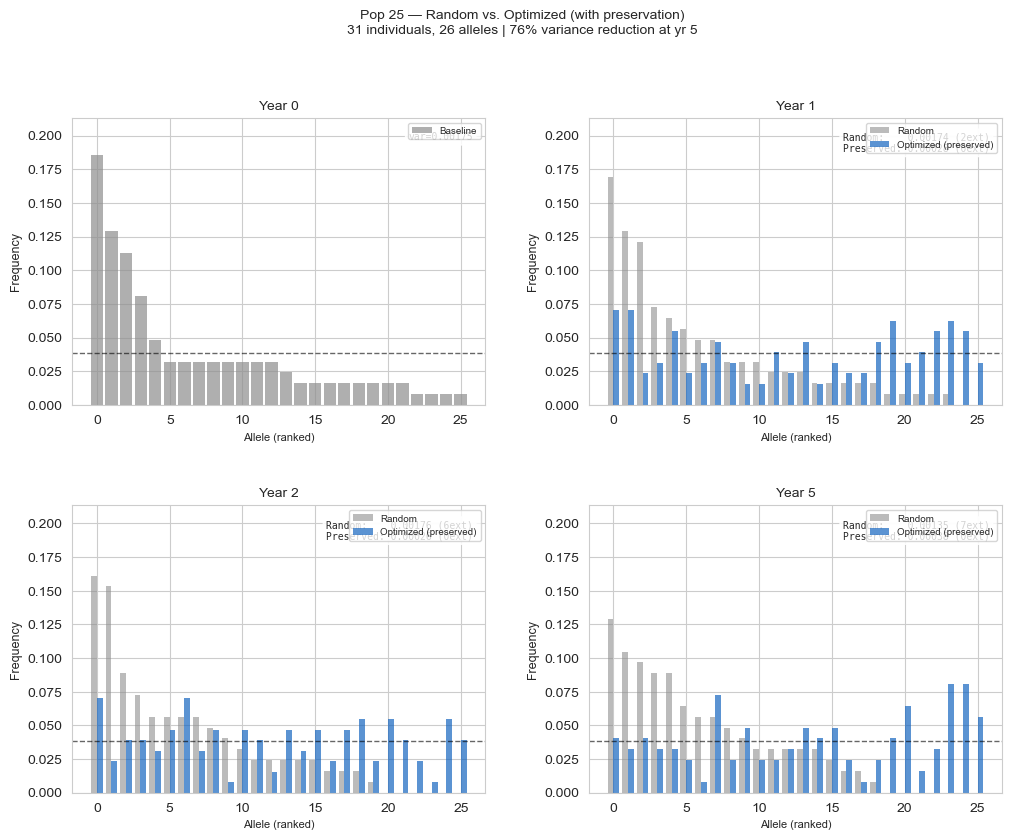

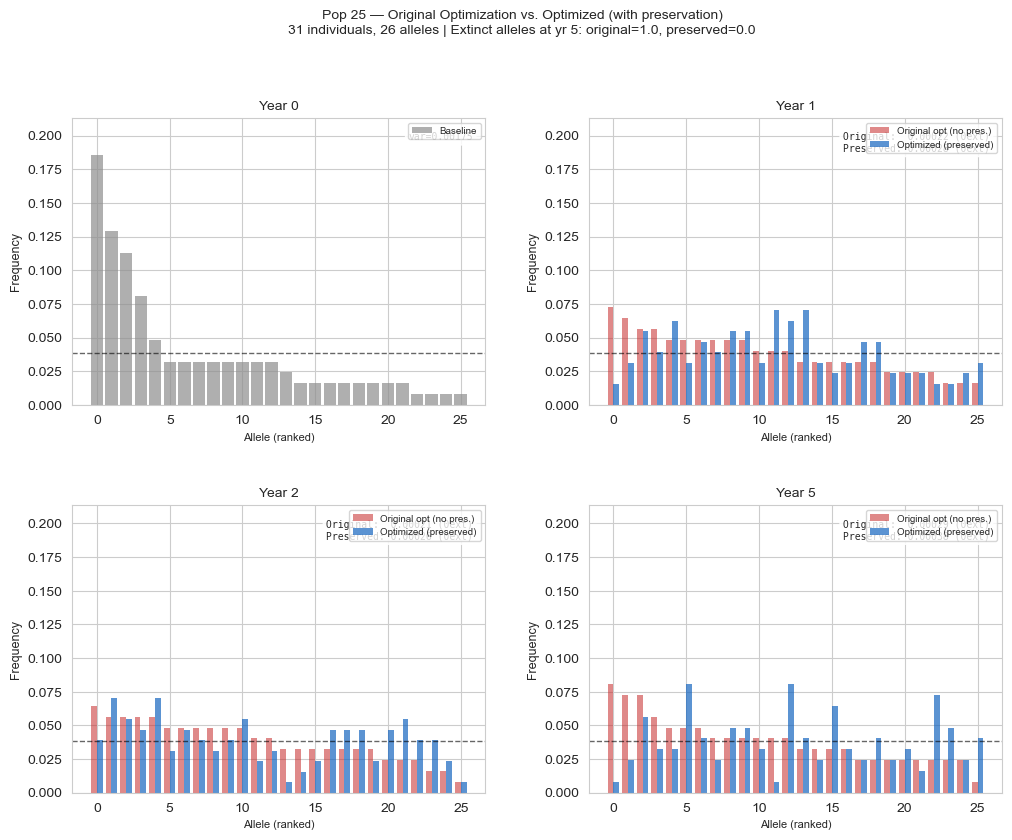

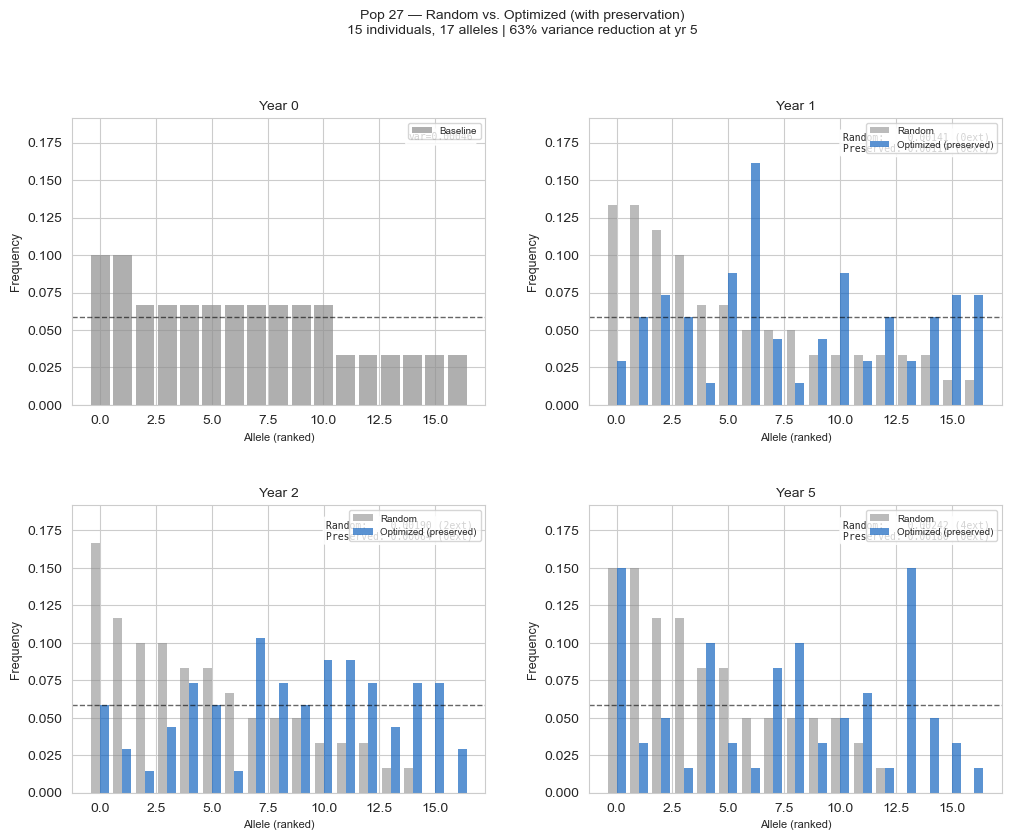

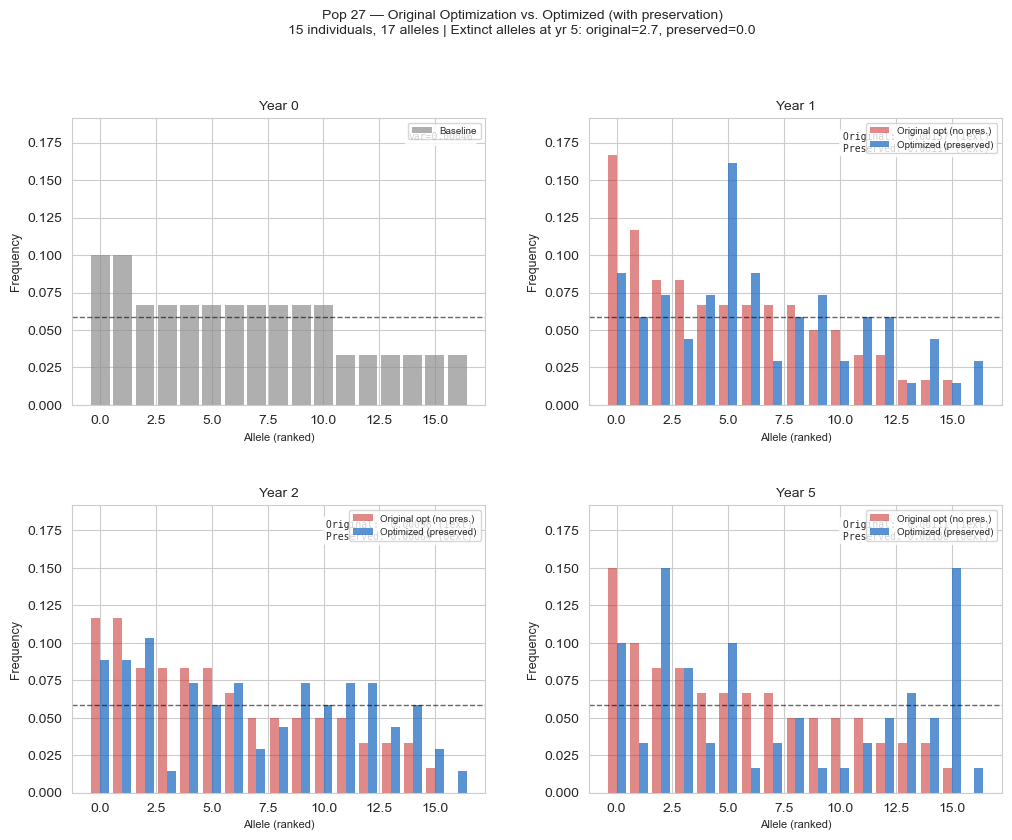

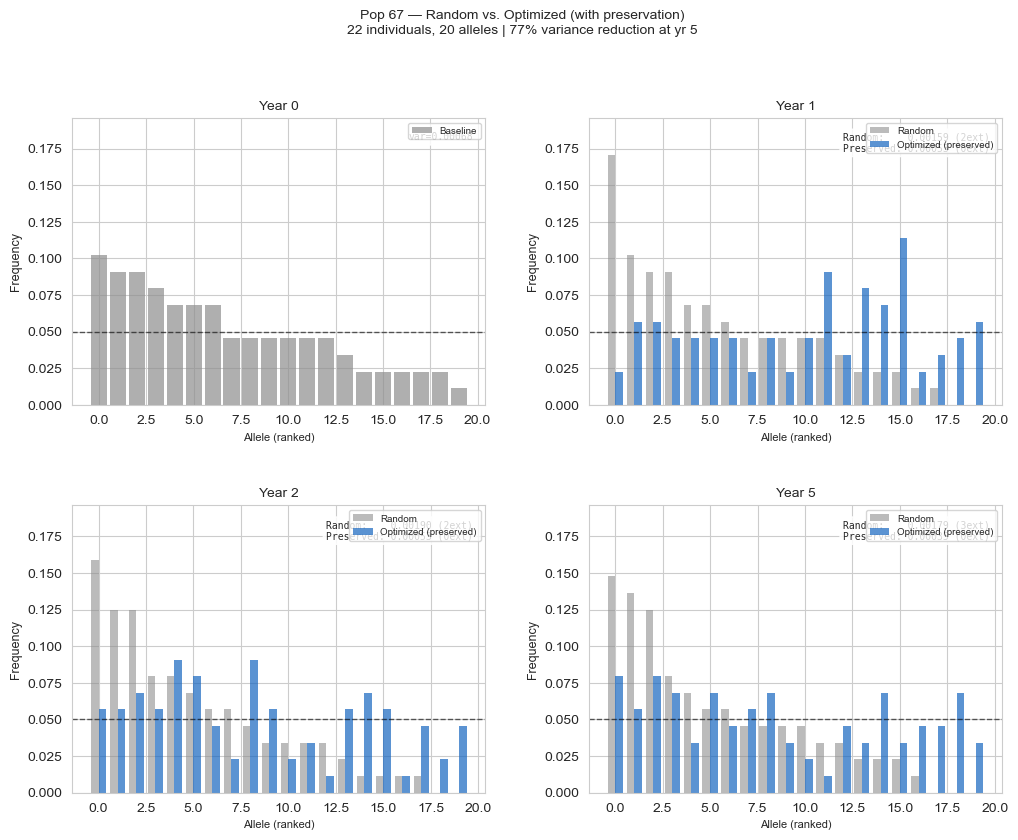

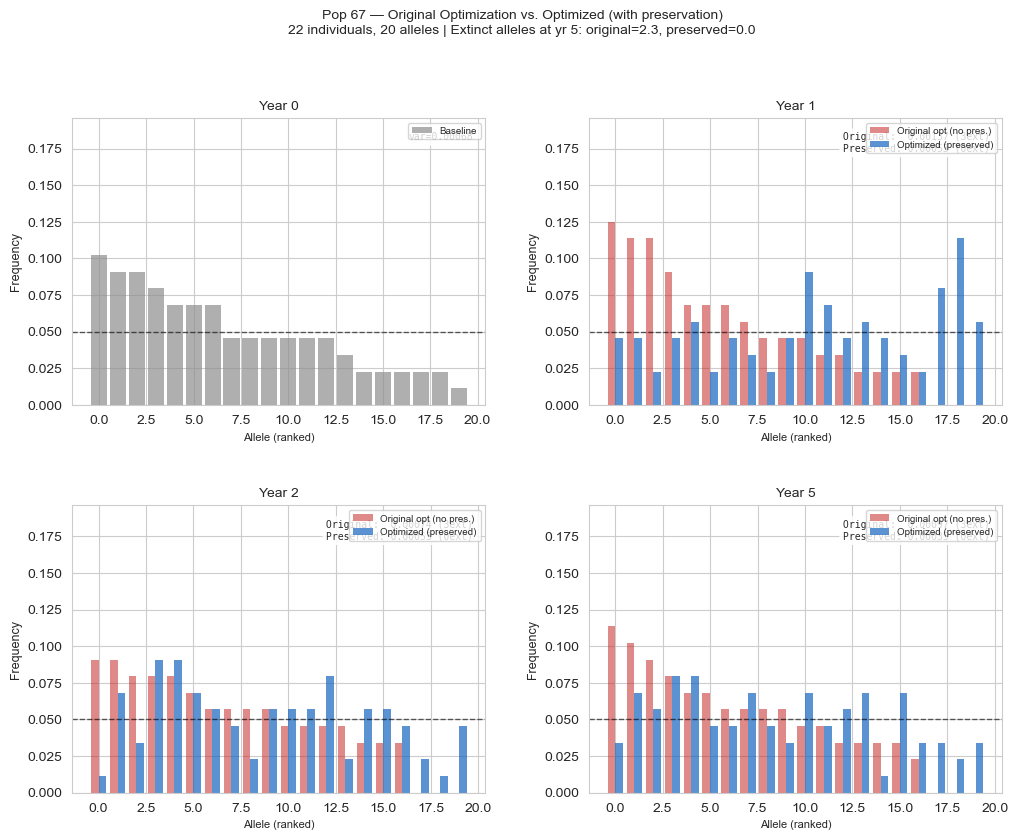

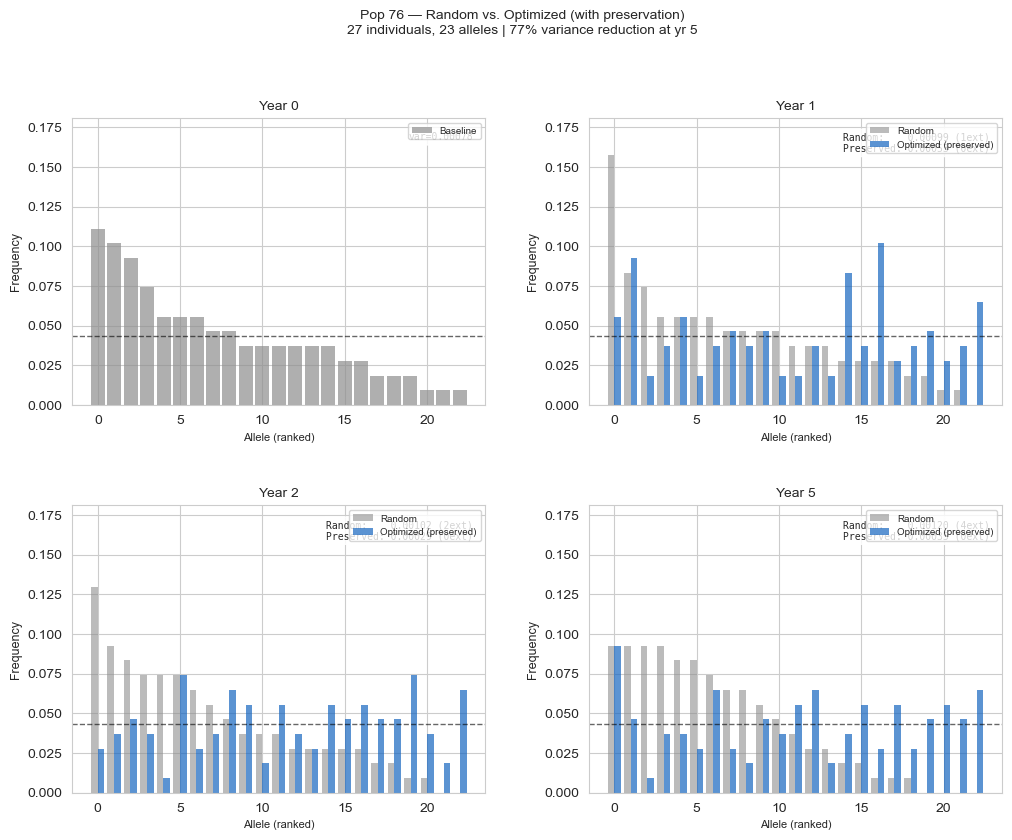

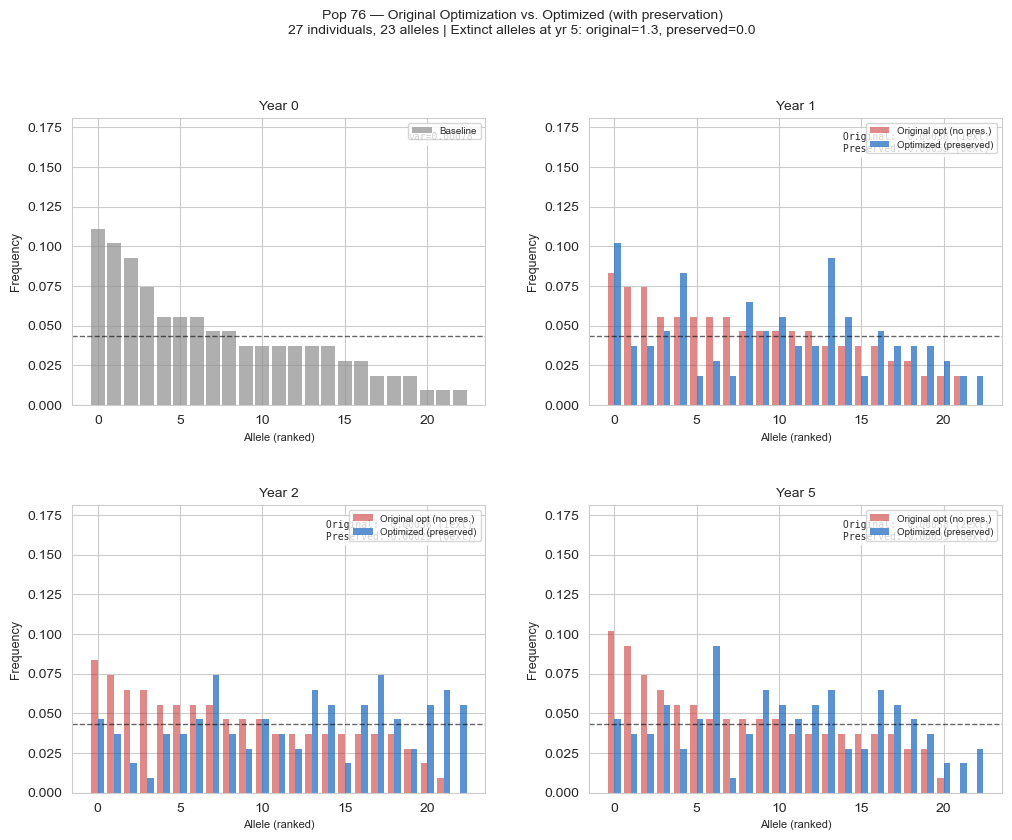

In [7]:
# Color scheme
COLOR_RANDOM = "#8e8e8e"      # gray — baseline
COLOR_PRESERVED = "#1565c0"   # blue — recommended strategy
COLOR_ORIGINAL = "#c62828"    # red — original opt (loses alleles)

for pop_id in major_pops:
    gd = group_data[pop_id]
    alleles = gd["allele_pool"]
    target = gd["target_freq"]
    n_ind = len(gd["pop"])
    n_alleles = len(alleles)

    # Determine consistent y-axis across all panels for this population
    y_max = 0
    for yr in SNAPSHOT_YEARS:
        for key in ["random", "optimized", "preserved"]:
            snap = gd[key]["snapshots"].get(yr, gd["pop"])
            f = allele_frequencies(snap, alleles)
            y_max = max(y_max, max(f.values()))
    y_max *= 1.15

    # ---- Chart Set 1: Random vs Optimized (with preservation) ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    yr5_improv_p = (1 - gd["preserved"]["variance_mean"][5] /
                    max(gd["random"]["variance_mean"][5], 1e-12)) * 100
    fig.suptitle(f"Pop {pop_id} — Random vs. Optimized (with preservation)\n"
                 f"{n_ind} individuals, {n_alleles} alleles | "
                 f"{yr5_improv_p:.0f}% variance reduction at yr 5",
                 fontsize=10)

    for idx, yr in enumerate(SNAPSHOT_YEARS):
        ax = axes[idx // 2, idx % 2]
        snap_random = gd["random"]["snapshots"].get(yr, gd["pop"])
        snap_preserved = gd["preserved"]["snapshots"].get(yr, gd["pop"])

        freqs_random = allele_frequencies(snap_random, alleles)
        freqs_preserved = allele_frequencies(snap_preserved, alleles)

        sorted_alleles = sorted(alleles, key=lambda a: freqs_random.get(a, 0), reverse=True)
        vals_random = [freqs_random.get(a, 0) for a in sorted_alleles]
        vals_preserved = [freqs_preserved.get(a, 0) for a in sorted_alleles]
        x = np.arange(len(sorted_alleles))

        if yr == 0:
            ax.bar(x, vals_random, width=0.85, color=COLOR_RANDOM, alpha=0.7,
                   edgecolor="none", label="Baseline")
            d_r = distance_from_equilibrium(snap_random, alleles)
            ax.text(0.97, 0.95, f"var={d_r['variance']:.5f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
        else:
            w = 0.4
            ax.bar(x - w/2, vals_random, width=w, color=COLOR_RANDOM, alpha=0.6,
                   edgecolor="none", label="Random")
            ax.bar(x + w/2, vals_preserved, width=w, color=COLOR_PRESERVED, alpha=0.7,
                   edgecolor="none", label="Optimized (preserved)")
            d_r = distance_from_equilibrium(snap_random, alleles)
            d_p = distance_from_equilibrium(snap_preserved, alleles)
            ax.text(0.97, 0.95,
                    f"Random:    {d_r['variance']:.5f} ({d_r['extinct_alleles']}ext)\n"
                    f"Preserved: {d_p['variance']:.5f} ({d_p['extinct_alleles']}ext)",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.axhline(y=target, color="black", linestyle="--", alpha=0.6, linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Allele (ranked)", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Year {yr}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    plt.subplots_adjust(top=0.86, hspace=0.35, wspace=0.25)
    plt.show()

    # ---- Chart Set 2: Original Optimization vs Optimized (with preservation) ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    yr5_ext_o = gd["optimized"]["extinct_mean"][5]
    yr5_ext_p = gd["preserved"]["extinct_mean"][5]
    fig.suptitle(f"Pop {pop_id} — Original Optimization vs. Optimized (with preservation)\n"
                 f"{n_ind} individuals, {n_alleles} alleles | "
                 f"Extinct alleles at yr 5: original={yr5_ext_o:.1f}, preserved={yr5_ext_p:.1f}",
                 fontsize=10)

    for idx, yr in enumerate(SNAPSHOT_YEARS):
        ax = axes[idx // 2, idx % 2]
        snap_original = gd["optimized"]["snapshots"].get(yr, gd["pop"])
        snap_preserved = gd["preserved"]["snapshots"].get(yr, gd["pop"])

        freqs_original = allele_frequencies(snap_original, alleles)
        freqs_preserved = allele_frequencies(snap_preserved, alleles)

        sorted_alleles = sorted(alleles, key=lambda a: freqs_original.get(a, 0), reverse=True)
        vals_original = [freqs_original.get(a, 0) for a in sorted_alleles]
        vals_preserved = [freqs_preserved.get(a, 0) for a in sorted_alleles]
        x = np.arange(len(sorted_alleles))

        if yr == 0:
            ax.bar(x, vals_original, width=0.85, color=COLOR_RANDOM, alpha=0.7,
                   edgecolor="none", label="Baseline")
            d_o = distance_from_equilibrium(snap_original, alleles)
            ax.text(0.97, 0.95, f"var={d_o['variance']:.5f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
        else:
            w = 0.4
            ax.bar(x - w/2, vals_original, width=w, color=COLOR_ORIGINAL, alpha=0.55,
                   edgecolor="none", label="Original opt (no pres.)")
            ax.bar(x + w/2, vals_preserved, width=w, color=COLOR_PRESERVED, alpha=0.7,
                   edgecolor="none", label="Optimized (preserved)")
            d_o = distance_from_equilibrium(snap_original, alleles)
            d_p = distance_from_equilibrium(snap_preserved, alleles)
            ax.text(0.97, 0.95,
                    f"Original:  {d_o['variance']:.5f} ({d_o['extinct_alleles']}ext)\n"
                    f"Preserved: {d_p['variance']:.5f} ({d_p['extinct_alleles']}ext)",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.axhline(y=target, color="black", linestyle="--", alpha=0.6, linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Allele (ranked)", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Year {yr}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    plt.subplots_adjust(top=0.86, hspace=0.35, wspace=0.25)
    plt.show()

### Within-Population Convergence: Preservation vs. Original Optimization

**Top row**: Variance trajectory over 5 years — lower is better. The preservation strategy (blue) tracks close to the original optimization (red) in variance reduction, while the original approach sacrifices allele diversity.

**Bottom row**: Allele extinction count — the key differentiator. The original optimization (red) loses alleles in several populations, while the preservation strategy (blue) prevents this.

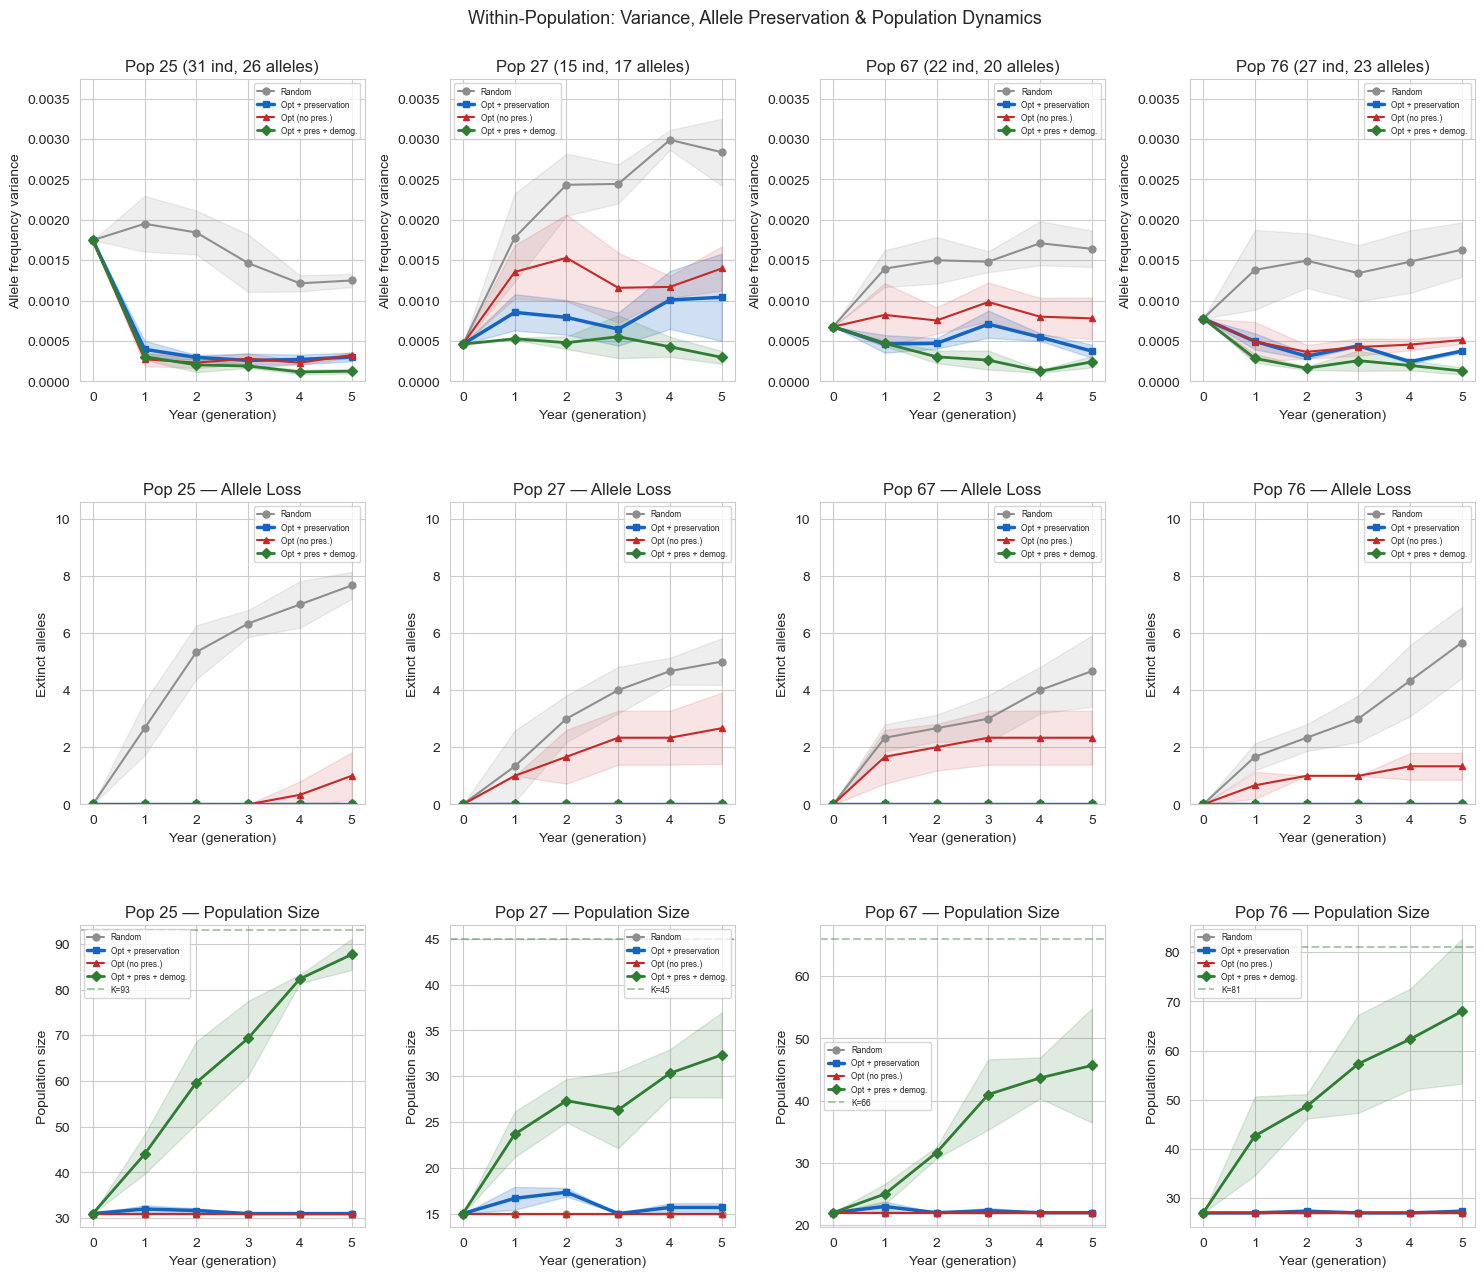

In [8]:
generations = np.arange(N_YEARS + 1)

# Consistent color scheme
COLOR_RANDOM = "#8e8e8e"
COLOR_PRESERVED = "#1565c0"
COLOR_ORIGINAL = "#c62828"
COLOR_DEMOGRAPHIC = "#2e7d32"

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

# Compute shared y-axis maxima
y_max_var = 0
y_max_ext = 0
for pop_id in major_pops:
    gd = group_data[pop_id]
    for key in ["random", "optimized", "preserved", "demographic"]:
        res = gd[key]
        upper = res["variance_mean"] + res["variance_std"]
        y_max_var = max(y_max_var, np.max(upper))
        upper_ext = res["extinct_mean"] + res["extinct_std"]
        y_max_ext = max(y_max_ext, np.max(upper_ext))
y_max_var *= 1.15
y_max_ext = max(y_max_ext * 1.3, 1)

strategy_specs = [
    ("random", "Random", COLOR_RANDOM, "o", 1.5, 0.15),
    ("preserved", "Opt + preservation", COLOR_PRESERVED, "s", 2.5, 0.2),
    ("optimized", "Opt (no pres.)", COLOR_ORIGINAL, "^", 1.5, 0.12),
    ("demographic", "Opt + pres + demog.", COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

for idx, pop_id in enumerate(major_pops):
    ax_var = axes[0, idx]
    ax_ext = axes[1, idx]
    ax_pop = axes[2, idx]
    gd = group_data[pop_id]

    for key, label, color, marker, lw, alpha in strategy_specs:
        res = gd[key]

        # Variance convergence (top row)
        ax_var.plot(generations, res["variance_mean"], f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
        ax_var.fill_between(generations,
                            res["variance_mean"] - res["variance_std"],
                            res["variance_mean"] + res["variance_std"],
                            alpha=alpha, color=color)

        # Allele loss (middle row)
        ax_ext.plot(generations, res["extinct_mean"], f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
        ax_ext.fill_between(generations,
                            res["extinct_mean"] - res["extinct_std"],
                            res["extinct_mean"] + res["extinct_std"],
                            alpha=alpha, color=color)

        # Population size (bottom row)
        ax_pop.plot(generations, res["pop_size_mean"], f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
        ax_pop.fill_between(generations,
                            res["pop_size_mean"] - res["pop_size_std"],
                            res["pop_size_mean"] + res["pop_size_std"],
                            alpha=alpha, color=color)

    N0 = len(gd["pop"])
    K = max(N0 * 3, 30)

    ax_var.set_xlabel("Year (generation)")
    ax_var.set_ylabel("Allele frequency variance")
    ax_var.set_title(f"Pop {pop_id} ({N0} ind, {len(gd['allele_pool'])} alleles)")
    ax_var.legend(fontsize=6)
    ax_var.set_xticks(generations)
    ax_var.set_ylim(0, y_max_var)

    ax_ext.set_xlabel("Year (generation)")
    ax_ext.set_ylabel("Extinct alleles")
    ax_ext.set_title(f"Pop {pop_id} — Allele Loss")
    ax_ext.legend(fontsize=6)
    ax_ext.set_xticks(generations)
    ax_ext.set_ylim(0, y_max_ext)

    ax_pop.axhline(K, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K}")
    ax_pop.set_xlabel("Year (generation)")
    ax_pop.set_ylabel("Population size")
    ax_pop.set_title(f"Pop {pop_id} — Population Size")
    ax_pop.legend(fontsize=6)
    ax_pop.set_xticks(generations)

plt.suptitle("Within-Population: Variance, Allele Preservation & Population Dynamics",
             fontsize=13)
plt.subplots_adjust(top=0.93, hspace=0.4, wspace=0.3)
plt.show()

### Strategy Comparison: Variance Reduction & Allele Loss

Quantify the % variance reduction and allele loss for each strategy vs. random mating. The preservation strategy is compared against both random (improvement) and the original optimization (allele safety).

Within-Population Strategy Comparison (including demographic dynamics)
Pres% = preservation vs random | Demo% = demographic vs random
Pop  N  K  Alleles  Initial var  Rand var (yr1)  Pres var (yr1)  Demo var (yr1) Pres% (yr1) Demo% (yr1)  Ext Rand (yr1)  Ext Pres (yr1)  Ext Demo (yr1) Pop size (yr1)  Rand var (yr2)  Pres var (yr2)  Demo var (yr2) Pres% (yr2) Demo% (yr2)  Ext Rand (yr2)  Ext Pres (yr2)  Ext Demo (yr2) Pop size (yr2)  Rand var (yr5)  Pres var (yr5)  Demo var (yr5) Pres% (yr5) Demo% (yr5)  Ext Rand (yr5)  Ext Pres (yr5)  Ext Demo (yr5) Pop size (yr5)
 25 31 93       26       0.0017          0.0020          0.0004          0.0003         80%         84%          2.6667          0.0000          0.0000             44          0.0018          0.0003          0.0002         84%         89%          5.3333          0.0000          0.0000             60          0.0012          0.0003          0.0001         76%         90%          7.6667          0.0000          0.0000        

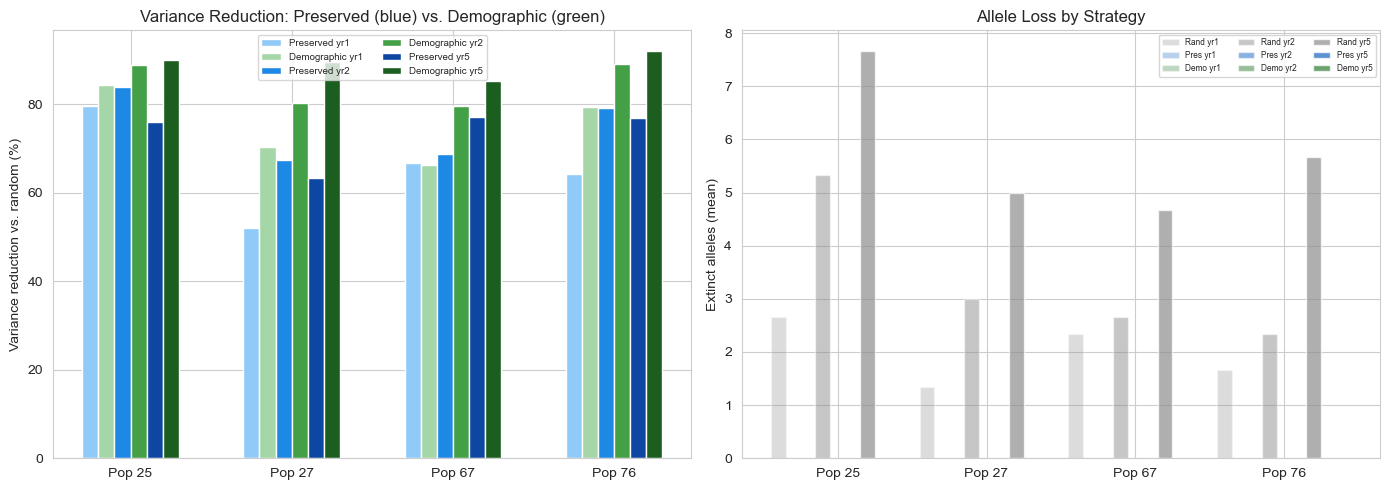

In [9]:
COLOR_RANDOM = "#8e8e8e"
COLOR_PRESERVED = "#1565c0"
COLOR_ORIGINAL = "#c62828"
COLOR_DEMOGRAPHIC = "#2e7d32"

improvement_rows = []
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]
    o = gd["optimized"]
    p = gd["preserved"]
    dm = gd["demographic"]
    N0 = len(gd["pop"])
    K = max(N0 * 3, 30)
    row = {"Pop": pop_id, "N": N0, "K": K, "Alleles": len(gd["allele_pool"]),
           "Initial var": r["variance_mean"][0]}
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]
        ov = o["variance_mean"][yr]
        pv = p["variance_mean"][yr]
        dv = dm["variance_mean"][yr]
        pct_p = (1 - pv / max(rv, 1e-12)) * 100
        pct_o = (1 - ov / max(rv, 1e-12)) * 100
        pct_d = (1 - dv / max(rv, 1e-12)) * 100
        row[f"Rand var (yr{yr})"] = rv
        row[f"Pres var (yr{yr})"] = pv
        row[f"Demo var (yr{yr})"] = dv
        row[f"Pres% (yr{yr})"] = f"{pct_p:.0f}%"
        row[f"Demo% (yr{yr})"] = f"{pct_d:.0f}%"
        row[f"Ext Rand (yr{yr})"] = r["extinct_mean"][yr]
        row[f"Ext Pres (yr{yr})"] = p["extinct_mean"][yr]
        row[f"Ext Demo (yr{yr})"] = dm["extinct_mean"][yr]
        row[f"Pop size (yr{yr})"] = f"{dm['pop_size_mean'][yr]:.0f}"
    improvement_rows.append(row)

imp_df = pd.DataFrame(improvement_rows)
print("Within-Population Strategy Comparison (including demographic dynamics)")
print("Pres% = preservation vs random | Demo% = demographic vs random")
print("=" * 140)
print(imp_df.to_string(index=False, float_format="{:.4f}".format))

# Bar chart: variance reduction % and allele extinction counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(major_pops))
width = 0.1

for i, yr in enumerate([1, 2, 5]):
    imps_p, imps_d, exts_r, exts_p, exts_d = [], [], [], [], []
    for pop_id in major_pops:
        gd = group_data[pop_id]
        rv = gd["random"]["variance_mean"][yr]
        pv = gd["preserved"]["variance_mean"][yr]
        dv = gd["demographic"]["variance_mean"][yr]
        imps_p.append((1 - pv / max(rv, 1e-12)) * 100)
        imps_d.append((1 - dv / max(rv, 1e-12)) * 100)
        exts_r.append(gd["random"]["extinct_mean"][yr])
        exts_p.append(gd["preserved"]["extinct_mean"][yr])
        exts_d.append(gd["demographic"]["extinct_mean"][yr])

    blue_shades = ["#90caf9", "#1e88e5", "#0d47a1"]
    green_shades = ["#a5d6a7", "#43a047", "#1b5e20"]
    ax1.bar(x + i * width * 2, imps_p, width, label=f"Preserved yr{yr}", color=blue_shades[i])
    ax1.bar(x + i * width * 2 + width, imps_d, width, label=f"Demographic yr{yr}", color=green_shades[i])

    ax2.bar(x + i * width * 3, exts_r, width, label=f"Rand yr{yr}", color=COLOR_RANDOM, alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + width, exts_p, width, label=f"Pres yr{yr}", color=COLOR_PRESERVED, alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + 2*width, exts_d, width, label=f"Demo yr{yr}", color=COLOR_DEMOGRAPHIC, alpha=0.3 + 0.2*i)

ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels([f"Pop {p}" for p in major_pops])
ax1.set_ylabel("Variance reduction vs. random (%)")
ax1.set_title("Variance Reduction: Preserved (blue) vs. Demographic (green)")
ax1.legend(fontsize=7, ncol=2)
ax1.axhline(y=0, color="gray", linewidth=0.5)

ax2.set_xticks(x + width * 4)
ax2.set_xticklabels([f"Pop {p}" for p in major_pops])
ax2.set_ylabel("Extinct alleles (mean)")
ax2.set_title("Allele Loss by Strategy")
ax2.legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

### Top Recommended Crosses (Per Population)

In [10]:
for pop_id in major_pops:
    gd = group_data[pop_id]
    cc = gd["compatible_crosses"]
    ow = gd["optimal_weights"]
    names = gd["individuals"]
    target = gd["target_freq"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    aem = gd["allele_effect_matrix"]

    rows = []
    for k in range(len(cc)):
        i, j, compat = cc[k]
        expected_freqs = aem[k]
        chi_sq = float(np.sum((expected_freqs - target) ** 2 / target))
        impact = d["chi_squared"] - chi_sq
        rows.append({
            "Maternal": names[i], "Pollen donor": names[j],
            "Compatibility": compat, "Impact score": impact,
            "Optimal weight": ow[k],
        })

    df = pd.DataFrame(rows)
    df_top = df.nlargest(10, "Optimal weight").copy()
    df_top.insert(0, "Rank", range(1, len(df_top) + 1))

    print(f"\n{'='*80}")
    print(f"Top 10 Crosses — Pop {pop_id} ({len(gd['pop'])} ind, {len(gd['allele_pool'])} alleles)")
    print(f"{'='*80}")
    print(df_top.to_string(index=False, float_format="{:.4f}".format))


Top 10 Crosses — Pop 25 (31 ind, 26 alleles)
 Rank             Maternal         Pollen donor  Compatibility  Impact score  Optimal weight
    1 Library003_barcode74 Library003_barcode61         0.1667       -2.6937          0.1538
    2 Library003_barcode74 Library003_barcode65         0.1667       -5.9437          0.0756
    3 Library002_barcode31 Library004_barcode83         1.0000       -4.3187          0.0190
    4 Library004_barcode83 Library002_barcode31         1.0000       -4.3187          0.0190
    5 Library004_barcode83 Library006_barcode42         1.0000       -4.3187          0.0190
    6 Library006_barcode42 Library004_barcode83         1.0000       -4.3187          0.0190
    7 Library004_barcode83 Library005_barcode35         1.0000       -4.3187          0.0190
    8 Library005_barcode35 Library004_barcode83         1.0000       -4.3187          0.0190
    9 Library003_barcode71 Library005_barcode24         1.0000       -4.3187          0.0144
   10 Library003_barcode

---

# Part B: Cross-Population Analysis

Treat all 124 ingroup individuals as a **single population** to find optimal crosses across population boundaries. This can introduce rare alleles from one population into another, accelerating species-wide convergence toward NFDS equilibrium.

In [11]:
%%time

global_alleles = sorted(set(a for g in population for a in g))
global_target = 1.0 / len(global_alleles)

print(f"Global population: {len(population)} individuals, {len(global_alleles)} alleles")
print(f"Target frequency: 1/{len(global_alleles)} = {global_target:.4f}")
print(f"Total directed pairs: {len(population) * (len(population) - 1)}")
print("\nEnumerating compatible crosses (this may take a moment)...")

global_cc, global_aem = enumerate_compatible_crosses(population, global_alleles)
n_total = len(population) * (len(population) - 1)

print(f"Compatible crosses: {len(global_cc)}/{n_total} ({100*len(global_cc)/n_total:.1f}%)")
print(f"Effect matrix shape: {global_aem.shape}")

Global population: 124 individuals, 92 alleles
Target frequency: 1/92 = 0.0109
Total directed pairs: 15252

Enumerating compatible crosses (this may take a moment)...
Compatible crosses: 15054/15252 (98.7%)
Effect matrix shape: (15054, 92)
CPU times: user 456 ms, sys: 17.9 ms, total: 474 ms
Wall time: 476 ms


In [12]:
%%time

# Baseline
w0 = np.ones(len(global_cc)) / len(global_cc)
expected = w0 @ global_aem
baseline_chi = float(np.sum((expected - global_target) ** 2 / global_target))

print(f"Optimizing over {len(global_cc)} crosses...")
global_optimal_weights, global_opt_result = compute_optimal_weights(
    global_cc, global_aem, global_alleles, maxiter=5000
)

print(f"Baseline chi²: {baseline_chi:.4f}")
print(f"Optimized chi²: {global_opt_result.fun:.6f}")
print(f"Converged: {global_opt_result.success}, iterations: {global_opt_result.nit}")

Optimizing over 15054 crosses...
Baseline chi²: 0.6808
Optimized chi²: 0.000000
Converged: True, iterations: 667
CPU times: user 3.01 s, sys: 1.04 s, total: 4.05 s
Wall time: 2.19 s


In [13]:
np.random.seed(42)
random.seed(42)

N_global = len(population)
K_global = max(N_global * 2, 200)  # species-wide carrying capacity

print(f"Simulating {N_YEARS} years for {N_global} individuals (K={K_global})...")
print("\nRandom mating...")
global_random = run_adaptive_simulation(population, global_alleles, N_YEARS, "random", N_TRIALS)

print("Optimized adaptive...")
global_optimized = run_adaptive_simulation(population, global_alleles, N_YEARS, "optimized", N_TRIALS)

print("Optimized + preservation...")
global_preserved = run_adaptive_simulation(
    population, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
)

print("Optimized + preservation + demography...")
global_demographic = run_adaptive_simulation(
    population, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
    carrying_capacity=K_global, growth_rate=0.5, demographic_stochastic=True,
)

print("\nResults:")
for yr in SNAPSHOT_YEARS:
    rv = global_random["variance_mean"][yr]
    ov = global_optimized["variance_mean"][yr]
    pv = global_preserved["variance_mean"][yr]
    dv = global_demographic["variance_mean"][yr]
    imp_o = (1 - ov / max(rv, 1e-12)) * 100
    imp_p = (1 - pv / max(rv, 1e-12)) * 100
    imp_d = (1 - dv / max(rv, 1e-12)) * 100
    print(f"  Year {yr}: Random var={rv:.6f}, Opt={ov:.6f} ({imp_o:.0f}%), "
          f"Pres={pv:.6f} ({imp_p:.0f}%), Demo={dv:.6f} ({imp_d:.0f}%)")
    print(f"           Extinct: R={global_random['extinct_mean'][yr]:.1f}, "
          f"O={global_optimized['extinct_mean'][yr]:.1f}, "
          f"P={global_preserved['extinct_mean'][yr]:.1f}, "
          f"D={global_demographic['extinct_mean'][yr]:.1f} | "
          f"Pop size (demo): {global_demographic['pop_size_mean'][yr]:.0f}")

Simulating 5 years for 124 individuals (K=248)...

Random mating...
Optimized adaptive...


/Users/jimbeck/.tmp/ipykernel_32609/1284015716.py:98: RuntimeWarning: Mean of empty slice
  "ne_mean": np.nanmean(all_ne, axis=0),
/opt/homebrew/Caskroom/miniforge/base/envs/polyploid-model/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Optimized + preservation...
Optimized + preservation + demography...

Results:
  Year 0: Random var=0.000087, Opt=0.000087 (0%), Pres=0.000087 (0%), Demo=0.000087 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 124
  Year 1: Random var=0.000126, Opt=0.000026 (80%), Pres=0.000039 (69%), Demo=0.000034 (73%)
           Extinct: R=7.3, O=0.7, P=0.0, D=0.0 | Pop size (demo): 162
  Year 2: Random var=0.000135, Opt=0.000024 (82%), Pres=0.000023 (83%), Demo=0.000018 (87%)
           Extinct: R=12.0, O=2.0, P=0.0, D=0.0 | Pop size (demo): 200
  Year 5: Random var=0.000142, Opt=0.000023 (84%), Pres=0.000022 (84%), Demo=0.000009 (93%)
           Extinct: R=25.3, O=2.7, P=0.0, D=0.0 | Pop size (demo): 227


### Cross-Population Allele Frequencies by Strategy

Same two-chart-set format as within-population:
- **Set 1**: Random vs. Optimized (with preservation) — the recommended strategy comparison
- **Set 2**: Original Optimization vs. Optimized (with preservation) — head-to-head of the two optimization approaches

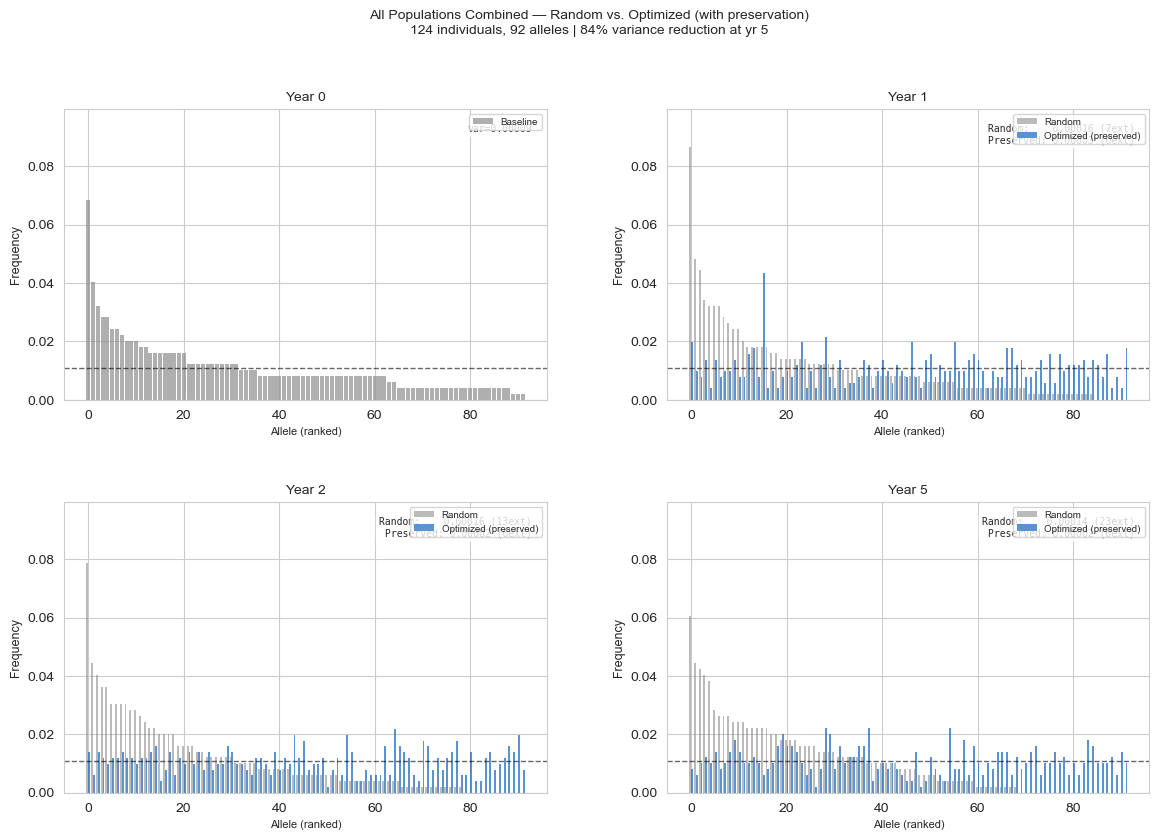

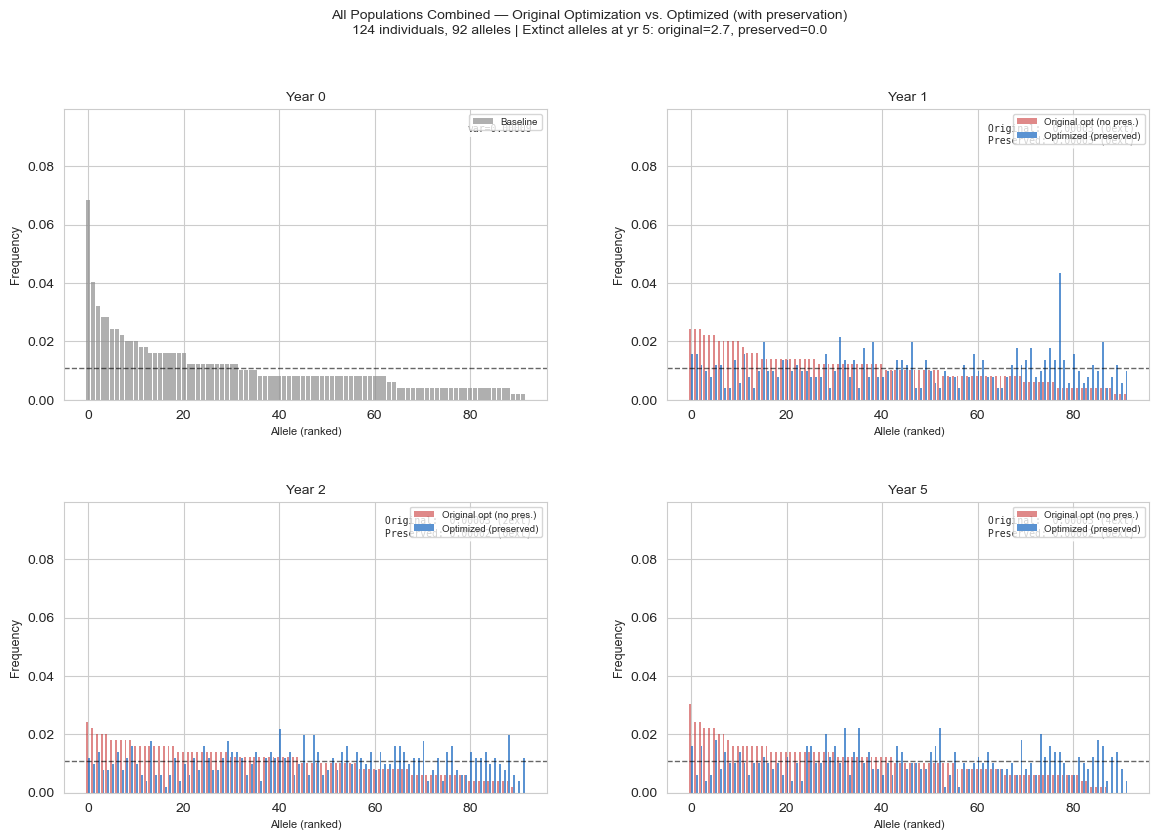

In [14]:
COLOR_RANDOM = "#8e8e8e"
COLOR_PRESERVED = "#1565c0"
COLOR_ORIGINAL = "#c62828"

yr5_rv = global_random["variance_mean"][5]
yr5_pv = global_preserved["variance_mean"][5]
yr5_ov = global_optimized["variance_mean"][5]
yr5_improv_p = (1 - yr5_pv / max(yr5_rv, 1e-12)) * 100
yr5_ext_o = global_optimized["extinct_mean"][5]
yr5_ext_p = global_preserved["extinct_mean"][5]

# Determine consistent y-axis across all panels
y_max = 0
for yr in SNAPSHOT_YEARS:
    for res in [global_random, global_optimized, global_preserved]:
        snap = res["snapshots"].get(yr, population)
        f = allele_frequencies(snap, global_alleles)
        y_max = max(y_max, max(f.values()))
y_max *= 1.15

# ---- Chart Set 1: Random vs Optimized (with preservation) ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"All Populations Combined — Random vs. Optimized (with preservation)\n"
             f"{len(population)} individuals, {len(global_alleles)} alleles | "
             f"{yr5_improv_p:.0f}% variance reduction at yr 5",
             fontsize=10)

for idx, yr in enumerate(SNAPSHOT_YEARS):
    ax = axes[idx // 2, idx % 2]
    snap_random = global_random["snapshots"].get(yr, population)
    snap_preserved = global_preserved["snapshots"].get(yr, population)

    freqs_random = allele_frequencies(snap_random, global_alleles)
    freqs_preserved = allele_frequencies(snap_preserved, global_alleles)

    sorted_alleles = sorted(global_alleles, key=lambda a: freqs_random.get(a, 0), reverse=True)
    vals_random = [freqs_random.get(a, 0) for a in sorted_alleles]
    vals_preserved = [freqs_preserved.get(a, 0) for a in sorted_alleles]
    x = np.arange(len(sorted_alleles))

    if yr == 0:
        ax.bar(x, vals_random, width=0.85, color=COLOR_RANDOM, alpha=0.7,
               edgecolor="none", label="Baseline")
        d_r = distance_from_equilibrium(snap_random, global_alleles)
        ax.text(0.97, 0.95, f"var={d_r['variance']:.5f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    else:
        w = 0.4
        ax.bar(x - w/2, vals_random, width=w, color=COLOR_RANDOM, alpha=0.6,
               edgecolor="none", label="Random")
        ax.bar(x + w/2, vals_preserved, width=w, color=COLOR_PRESERVED, alpha=0.7,
               edgecolor="none", label="Optimized (preserved)")
        d_r = distance_from_equilibrium(snap_random, global_alleles)
        d_p = distance_from_equilibrium(snap_preserved, global_alleles)
        ax.text(0.97, 0.95,
                f"Random:    {d_r['variance']:.5f} ({d_r['extinct_alleles']}ext)\n"
                f"Preserved: {d_p['variance']:.5f} ({d_p['extinct_alleles']}ext)",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

    ax.axhline(y=global_target, color="black", linestyle="--", alpha=0.6, linewidth=1)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("Allele (ranked)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.set_title(f"Year {yr}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")

plt.subplots_adjust(top=0.87, hspace=0.35, wspace=0.25)
plt.show()

# ---- Chart Set 2: Original Optimization vs Optimized (with preservation) ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"All Populations Combined — Original Optimization vs. Optimized (with preservation)\n"
             f"{len(population)} individuals, {len(global_alleles)} alleles | "
             f"Extinct alleles at yr 5: original={yr5_ext_o:.1f}, preserved={yr5_ext_p:.1f}",
             fontsize=10)

for idx, yr in enumerate(SNAPSHOT_YEARS):
    ax = axes[idx // 2, idx % 2]
    snap_original = global_optimized["snapshots"].get(yr, population)
    snap_preserved = global_preserved["snapshots"].get(yr, population)

    freqs_original = allele_frequencies(snap_original, global_alleles)
    freqs_preserved = allele_frequencies(snap_preserved, global_alleles)

    sorted_alleles = sorted(global_alleles, key=lambda a: freqs_original.get(a, 0), reverse=True)
    vals_original = [freqs_original.get(a, 0) for a in sorted_alleles]
    vals_preserved = [freqs_preserved.get(a, 0) for a in sorted_alleles]
    x = np.arange(len(sorted_alleles))

    if yr == 0:
        ax.bar(x, vals_original, width=0.85, color=COLOR_RANDOM, alpha=0.7,
               edgecolor="none", label="Baseline")
        d_o = distance_from_equilibrium(snap_original, global_alleles)
        ax.text(0.97, 0.95, f"var={d_o['variance']:.5f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    else:
        w = 0.4
        ax.bar(x - w/2, vals_original, width=w, color=COLOR_ORIGINAL, alpha=0.55,
               edgecolor="none", label="Original opt (no pres.)")
        ax.bar(x + w/2, vals_preserved, width=w, color=COLOR_PRESERVED, alpha=0.7,
               edgecolor="none", label="Optimized (preserved)")
        d_o = distance_from_equilibrium(snap_original, global_alleles)
        d_p = distance_from_equilibrium(snap_preserved, global_alleles)
        ax.text(0.97, 0.95,
                f"Original:  {d_o['variance']:.5f} ({d_o['extinct_alleles']}ext)\n"
                f"Preserved: {d_p['variance']:.5f} ({d_p['extinct_alleles']}ext)",
                transform=ax.transAxes, ha="right", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

    ax.axhline(y=global_target, color="black", linestyle="--", alpha=0.6, linewidth=1)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("Allele (ranked)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.set_title(f"Year {yr}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")

plt.subplots_adjust(top=0.87, hspace=0.35, wspace=0.25)
plt.show()

### Cross-Population Convergence: Preservation vs. Original Optimization

Three panels: variance, chi-squared distance, and allele extinction. The preservation strategy (blue) achieves strong variance reduction while the allele loss panel demonstrates its key advantage over the original approach (red).

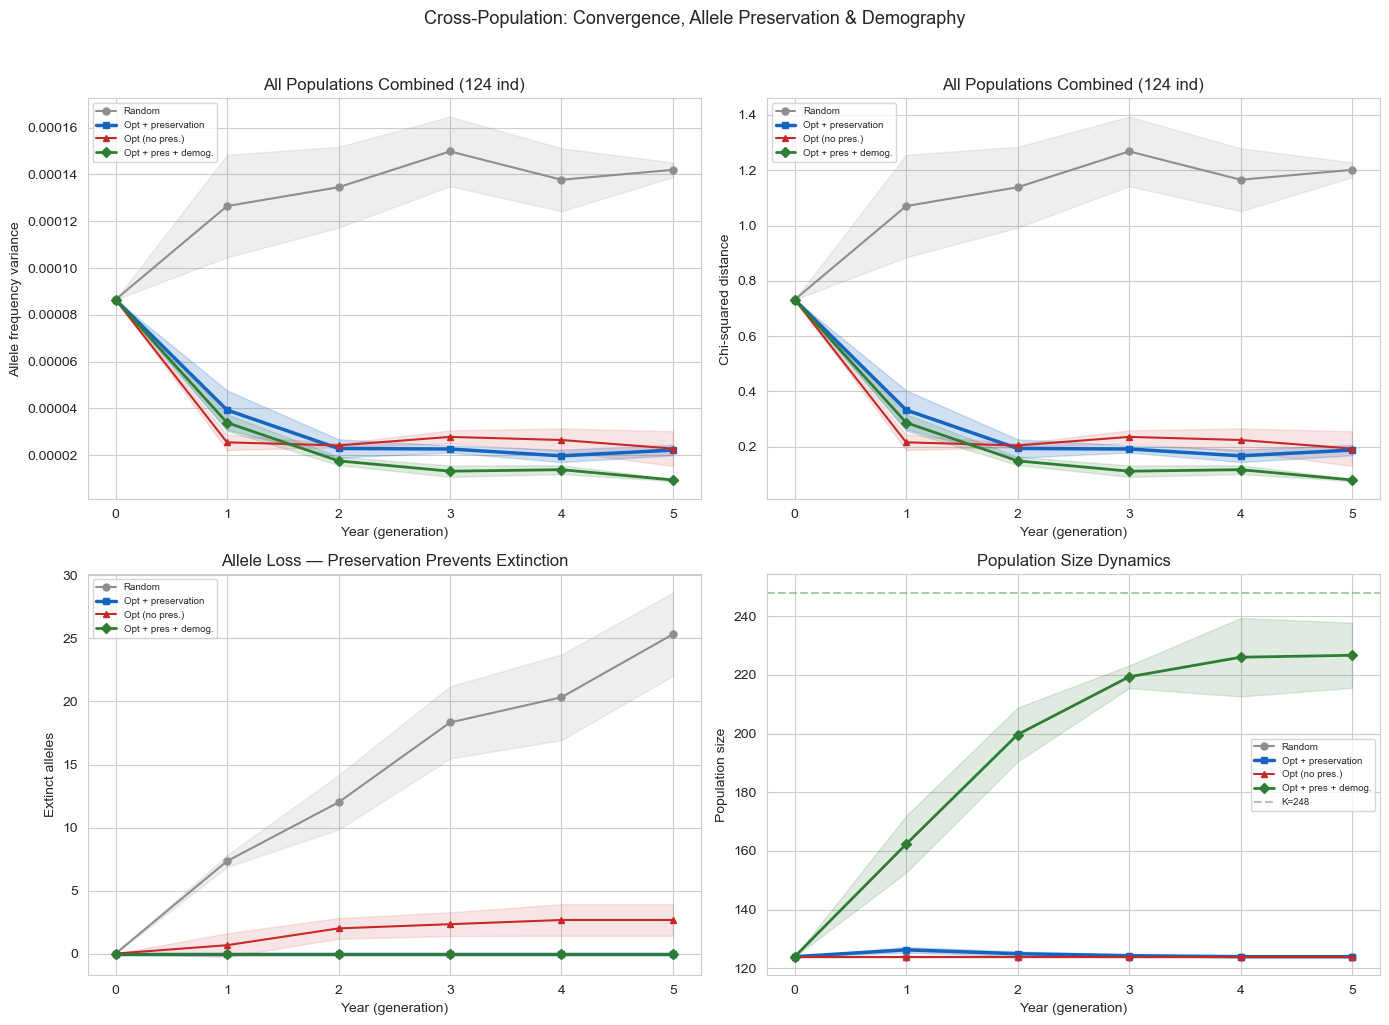

In [15]:
COLOR_RANDOM = "#8e8e8e"
COLOR_PRESERVED = "#1565c0"
COLOR_ORIGINAL = "#c62828"
COLOR_DEMOGRAPHIC = "#2e7d32"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strategy_specs = [
    (global_random, "Random", COLOR_RANDOM, "o", 1.5, 0.15),
    (global_preserved, "Opt + preservation", COLOR_PRESERVED, "s", 2.5, 0.2),
    (global_optimized, "Opt (no pres.)", COLOR_ORIGINAL, "^", 1.5, 0.12),
    (global_demographic, "Opt + pres + demog.", COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

for ax, (metric, ylabel) in zip(axes[0], [
    ("variance_mean", "Allele frequency variance"),
    ("chi_sq_mean", "Chi-squared distance"),
]):
    for res, label, color, marker, lw, alpha in strategy_specs:
        ax.plot(generations, res[metric], f"-{marker}", color=color,
                markersize=5, label=label, linewidth=lw)
        std_key = metric.replace('mean', 'std')
        ax.fill_between(generations,
                        res[metric] - res[std_key],
                        res[metric] + res[std_key],
                        alpha=alpha, color=color)

    ax.set_xlabel("Year (generation)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"All Populations Combined ({len(population)} ind)")
    ax.legend(fontsize=7)
    ax.set_xticks(generations)

# Allele loss panel
ax_ext = axes[1, 0]
for res, label, color, marker, lw, alpha in strategy_specs:
    ax_ext.plot(generations, res["extinct_mean"], f"-{marker}", color=color,
                markersize=5, label=label, linewidth=lw)
    ax_ext.fill_between(generations,
                        res["extinct_mean"] - res["extinct_std"],
                        res["extinct_mean"] + res["extinct_std"],
                        alpha=alpha, color=color)

ax_ext.set_xlabel("Year (generation)")
ax_ext.set_ylabel("Extinct alleles")
ax_ext.set_title("Allele Loss — Preservation Prevents Extinction")
ax_ext.legend(fontsize=7)
ax_ext.set_xticks(generations)

# Population size panel
ax_pop = axes[1, 1]
for res, label, color, marker, lw, alpha in strategy_specs:
    ax_pop.plot(generations, res["pop_size_mean"], f"-{marker}", color=color,
                markersize=5, label=label, linewidth=lw)
    ax_pop.fill_between(generations,
                        res["pop_size_mean"] - res["pop_size_std"],
                        res["pop_size_mean"] + res["pop_size_std"],
                        alpha=alpha, color=color)

ax_pop.axhline(K_global, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K_global}")
ax_pop.set_xlabel("Year (generation)")
ax_pop.set_ylabel("Population size")
ax_pop.set_title("Population Size Dynamics")
ax_pop.legend(fontsize=7)
ax_pop.set_xticks(generations)

plt.suptitle("Cross-Population: Convergence, Allele Preservation & Demography",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Top Cross-Population Recommended Crosses

These crosses may span population boundaries, introducing alleles between populations.

In [16]:
d_global = distance_from_equilibrium(population, global_alleles)

rows = []
for k in range(len(global_cc)):
    i, j, compat = global_cc[k]
    expected_freqs = global_aem[k]
    chi_sq = float(np.sum((expected_freqs - global_target) ** 2 / global_target))
    impact = d_global["chi_squared"] - chi_sq
    rows.append({
        "Maternal": individual_names[i],
        "Mat. Pop": pop_map[individual_names[i]],
        "Pollen donor": individual_names[j],
        "Don. Pop": pop_map[individual_names[j]],
        "Cross type": "inter-pop" if pop_map[individual_names[i]] != pop_map[individual_names[j]] else "intra-pop",
        "Compatibility": compat,
        "Impact score": impact,
        "Optimal weight": global_optimal_weights[k],
    })

df_global = pd.DataFrame(rows)
df_top = df_global.nlargest(20, "Optimal weight").copy()
df_top.insert(0, "Rank", range(1, len(df_top) + 1))

print("Top 20 Cross-Population Crosses")
print("=" * 120)
print(df_top.to_string(index=False, float_format="{:.4f}".format))

# Summary of inter vs intra
n_inter = (df_global["Cross type"] == "inter-pop").sum()
n_intra = (df_global["Cross type"] == "intra-pop").sum()
top20_inter = (df_top["Cross type"] == "inter-pop").sum()
print(f"\nAll compatible crosses: {n_intra} intra-pop, {n_inter} inter-pop")
print(f"Top 20 by weight: {20 - top20_inter} intra-pop, {top20_inter} inter-pop")

Top 20 Cross-Population Crosses
 Rank             Maternal Mat. Pop         Pollen donor Don. Pop Cross type  Compatibility  Impact score  Optimal weight
    1 Library003_barcode74       25 Library003_barcode61       25  intra-pop         0.1667      -15.5178          0.0358
    2 Library006_barcode59       67 Library003_barcode74       25  inter-pop         0.5000      -11.6845          0.0220
    3 Library003_barcode74       25 Library003_barcode65       25  intra-pop         0.1667      -27.0178          0.0216
    4 Library005_barcode07       76 Library005_barcode35       25  inter-pop         0.1667      -27.0178          0.0207
    5 Library004_barcode87       76 Library005_barcode20       76  intra-pop         0.1667      -32.7678          0.0167
    6 Library005_barcode08       76 Library002_barcode35       52  inter-pop         0.1667      -29.8928          0.0144
    7 Library005_barcode01       76 Library001_barcode18     26-3  inter-pop         0.1667      -29.8928         

---

## Summary: All Analyses

Compare within-population and cross-population results. The preservation-aware strategy ("Pres%") is compared against random mating, alongside the original optimization ("Orig%"). Extinct allele counts (Ext) show the critical difference: preservation prevents allele loss.

In [17]:
summary_rows = []

# Within-population rows
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]
    o = gd["optimized"]
    p = gd["preserved"]
    dm = gd["demographic"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    N0 = len(gd["pop"])
    K = max(N0 * 3, 30)
    row = {
        "Analysis": f"Pop {pop_id}",
        "N": N0,
        "K": K,
        "Alleles": len(gd["allele_pool"]),
        "Crosses": len(gd["compatible_crosses"]),
        "Initial chi-sq": d["chi_squared"],
        "Optimized chi-sq": gd["opt_result"].fun,
    }
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]
        pv = p["variance_mean"][yr]
        dv = dm["variance_mean"][yr]
        row[f"Yr{yr} Rand var"] = rv
        row[f"Yr{yr} Pres var"] = pv
        row[f"Yr{yr} Demo var"] = dv
        row[f"Yr{yr} Pres%"] = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Yr{yr} Demo%"] = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Yr{yr} Ext(R/P/D)"] = (f"{r['extinct_mean'][yr]:.0f}/"
                                       f"{p['extinct_mean'][yr]:.0f}/"
                                       f"{dm['extinct_mean'][yr]:.0f}")
        row[f"Yr{yr} Pop(D)"] = f"{dm['pop_size_mean'][yr]:.0f}"
    summary_rows.append(row)

# Cross-population row
row = {
    "Analysis": "ALL (cross-pop)",
    "N": len(population),
    "K": K_global,
    "Alleles": len(global_alleles),
    "Crosses": len(global_cc),
    "Initial chi-sq": d_global["chi_squared"],
    "Optimized chi-sq": global_opt_result.fun,
}
for yr in [1, 2, 5]:
    rv = global_random["variance_mean"][yr]
    pv = global_preserved["variance_mean"][yr]
    dv = global_demographic["variance_mean"][yr]
    row[f"Yr{yr} Rand var"] = rv
    row[f"Yr{yr} Pres var"] = pv
    row[f"Yr{yr} Demo var"] = dv
    row[f"Yr{yr} Pres%"] = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
    row[f"Yr{yr} Demo%"] = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
    row[f"Yr{yr} Ext(R/P/D)"] = (f"{global_random['extinct_mean'][yr]:.0f}/"
                                   f"{global_preserved['extinct_mean'][yr]:.0f}/"
                                   f"{global_demographic['extinct_mean'][yr]:.0f}")
    row[f"Yr{yr} Pop(D)"] = f"{global_demographic['pop_size_mean'][yr]:.0f}"
summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("Complete Analysis Summary (including demographic dynamics)")
print("Pres% = preservation vs random | Demo% = demographic vs random")
print("Ext = Random/Preserved/Demographic | Pop(D) = demographic population size")
print("=" * 160)
print(summary_df.to_string(index=False, float_format="{:.6f}".format))

Complete Analysis Summary (including demographic dynamics)
Pres% = preservation vs random | Demo% = demographic vs random
Ext = Random/Preserved/Demographic | Pop(D) = demographic population size
       Analysis   N   K  Alleles  Crosses  Initial chi-sq  Optimized chi-sq  Yr1 Rand var  Yr1 Pres var  Yr1 Demo var Yr1 Pres% Yr1 Demo% Yr1 Ext(R/P/D) Yr1 Pop(D)  Yr2 Rand var  Yr2 Pres var  Yr2 Demo var Yr2 Pres% Yr2 Demo% Yr2 Ext(R/P/D) Yr2 Pop(D)  Yr5 Rand var  Yr5 Pres var  Yr5 Demo var Yr5 Pres% Yr5 Demo% Yr5 Ext(R/P/D) Yr5 Pop(D)
         Pop 25  31  93       26      871        1.181322          0.000001      0.001951      0.000397      0.000306       80%       84%          3/0/0         44      0.001843      0.000298      0.000205       84%       89%          5/0/0         60      0.001249      0.000302      0.000126       76%       90%          8/0/0         88
         Pop 27  15  45       17      206        0.133333          0.000000      0.001779      0.000854      0.000528       

## Validation

Spot-check key invariants on the real data pipeline.

In [18]:
all_ok = True

# Check within-pop analyses
for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    cc = gd["compatible_crosses"]
    print(f"--- Pop {pop_id} ---")

    freq_sum = sum(allele_frequencies(pop, alleles).values())
    ok = abs(freq_sum - 1.0) < 1e-10
    print(f"  Freq sum = {freq_sum:.10f} {'OK' if ok else 'FAIL'}")
    all_ok &= ok

    self_ok = all(crossing_compatibility(pop[i], pop[i]) == 0.0 for i in range(len(pop)))
    print(f"  Self-incompatibility: {'OK' if self_ok else 'FAIL'}")
    all_ok &= self_ok

    print(f"  Optimizer converged: {gd['opt_result'].success}")

# Check global analysis
print(f"\n--- Global ---")
freq_sum = sum(allele_frequencies(population, global_alleles).values())
ok = abs(freq_sum - 1.0) < 1e-10
print(f"  Freq sum = {freq_sum:.10f} {'OK' if ok else 'FAIL'}")
all_ok &= ok
print(f"  Optimizer converged: {global_opt_result.success}")

# Offspring spot-check
n_checked = 0
offspring_ok = True
for k in range(min(20, len(global_cc))):
    i, j, _ = global_cc[k]
    offspring_dist = cross(population[i], population[j])
    parent_alleles = set(population[i]) | set(population[j])
    for g in offspring_dist:
        if len(g) != 4 or not all(a in parent_alleles for a in g):
            offspring_ok = False
        n_checked += 1
print(f"  Offspring spot-check ({n_checked} genotypes): {'OK' if offspring_ok else 'FAIL'}")
all_ok &= offspring_ok

print(f"\n{'='*40}")
print(f"{'All checks passed.' if all_ok else 'WARNING: Some checks failed.'}")

--- Pop 25 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 27 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 67 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True
--- Pop 76 ---
  Freq sum = 1.0000000000 OK
  Self-incompatibility: OK
  Optimizer converged: True

--- Global ---
  Freq sum = 1.0000000000 OK
  Optimizer converged: True
  Offspring spot-check (108 genotypes): OK

All checks passed.
